<a href="https://colab.research.google.com/github/gretazehnder/algorithms-for-massive-datasets-project/blob/main/market_basket_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Market basket analysis - IMDB dataset

Movies are modeled as transactions (baskets), and the actors listed in Star1-Star4 are treated as items.  
The goal is to discover frequent co-acting patterns using FP-Growth.

## Environment setup

Install required libraries (for Colab execution)

In [ ]:
!pip -q install mlxtend

Import necessary libraries

In [ ]:
import os
import pandas as pd
from collections import Counter
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import warnings
import itertools
import math

warnings.filterwarnings("ignore", category=DeprecationWarning)

## Dataset download

The dataset is downloaded using the Kaggle API.

In [ ]:
os.environ['KAGGLE_USERNAME'] = "xxxxx"
os.environ['KAGGLE_KEY'] = "xxxxx"
!kaggle datasets download -d "harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows"


Dataset URL: https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows
License(s): CC0-1.0
imdb-dataset-of-top-1000-movies-and-tv-shows.zip: Skipping, found more recently modified local copy (use --force to force download)


The compressed file is then extracted before loading the data.

In [ ]:
!unzip "*.zip"

Archive:  imdb-dataset-of-top-1000-movies-and-tv-shows.zip
replace imdb_top_1000.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: imdb_top_1000.csv       


## Data loading

The dataset is loaded into a pandas dataframe and inspected to check its shape and to identify relevant columns.

In [ ]:
df = pd.read_csv("imdb_top_1000.csv")
df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [ ]:
df.shape

(1000, 16)

The dataset is composed of 1000 rows and 16 columns.  Let's now inspect the columns:

In [ ]:
df.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

The dataset contains information about the top 1000 movies and TV shows, including metadata such as title, genre, rating, and main actors.

For this project, we focus only on the actor columns.

## Data preprocessing

We select only the actor columns (Star1–Star4), remove missing values, and convert each movie into a transaction containing its four actors.

Let's start with column selection:

In [ ]:
df = df[['Star1', 'Star2', 'Star3', 'Star4']]
df.head()

,Star1,Star2,Star3,Star4
0,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler
1,Marlon Brando,Al Pacino,James Caan,Diane Keaton
2,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine
3,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton
4,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler


Drop missing values:

In [ ]:
df = df.dropna()

Double-check:

In [ ]:
df.shape

(1000, 4)

Now we are working with a dataset composed of 1000 rows and the 4 selected columns: Star1, Star2, Star3, Star4.

Now, each movie needs to be converted into a transaction containing its four main actors.

In [ ]:
transactions = df.values.tolist()
transactions[:5]

[['Tim Robbins', 'Morgan Freeman', 'Bob Gunton', 'William Sadler'],
 ['Marlon Brando', 'Al Pacino', 'James Caan', 'Diane Keaton'],
 ['Christian Bale', 'Heath Ledger', 'Aaron Eckhart', 'Michael Caine'],
 ['Al Pacino', 'Robert De Niro', 'Robert Duvall', 'Diane Keaton'],
 ['Henry Fonda', 'Lee J. Cobb', 'Martin Balsam', 'John Fiedler']]

## Exploratory analysis and support selection

In this phase we analyze the frequency distribution of actors.

This step allows us to:

- Determine the number of distinct actors (items).
- Identify the most frequently appearing actors.
- Choose an appropriate minimum support threshold.

Filtering actors below the minimum support reduces the number of distinct items (columns in the one-hot matrix), which lowers memory usage and speeds up frequent itemset mining.  
This makes the approach more scalable to larger datasets with many distinct actors.

In [ ]:
item_counts = Counter()

for basket in transactions:
    item_counts.update(basket)

print("Number of distinct actors:", len(item_counts))
print("\nTop 10 most frequent actors:")
item_counts.most_common(10)

Number of distinct actors: 2709

Top 10 most frequent actors:


[('Robert De Niro', 17),
 ('Tom Hanks', 14),
 ('Al Pacino', 13),
 ('Brad Pitt', 12),
 ('Clint Eastwood', 12),
 ('Christian Bale', 11),
 ('Leonardo DiCaprio', 11),
 ('Matt Damon', 11),
 ('James Stewart', 10),
 ('Michael Caine', 9)]

Based on the frequency analysis, we set the minimum support to 1% (at least 10 movies).  
Actors below this threshold are removed to reduce dimensionality and improve computational efficiency.

In [ ]:
min_support = 0.01
min_count = int(min_support * len(transactions))

allowed_items = {item for item, count in item_counts.items() if count >= min_count}

print("Minimum count threshold:", min_count)
print("Actors remaining:", len(allowed_items))

Minimum count threshold: 10
Actors remaining: 9


With a 1% minimum support (10 movies), only a very small number of actors remain, and the number of resulting baskets is significantly reduced.

This threshold appears too restrictive, limiting the discovery of meaningful co-occurrence patterns.

To obtain a richer set of frequent itemsets while preserving scalability, we reduce the minimum support to 0.5% (at least 5 movies).

In [ ]:
min_support = 0.005
min_count = int(min_support * len(transactions))

allowed_items = {item for item, count in item_counts.items() if count >= min_count}

transactions_filtered = [
    [item for item in basket if item in allowed_items]
    for basket in transactions
]
transactions_filtered = [t for t in transactions_filtered if len(t) > 0]

print("Minimum count threshold:", min_count)
print("Actors remaining:", len(allowed_items))
print("Baskets remaining:", len(transactions_filtered))

Minimum count threshold: 5
Actors remaining: 79
Baskets remaining: 399


With a 0.5% support threshold, 79 actors remain and 399 movies contain at least one of them.  
This provides a richer and more informative dataset while maintaining computational feasibility.

## Transaction encoding (sparse\) for Apriori

Let's convert transactions into a one-hot encoded matrix required by Apriori.
A sparse representation is used to reduce memory usage and improve scalability.

In [ ]:
te = TransactionEncoder()
X = te.fit(transactions_filtered).transform(transactions_filtered, sparse=True)

df_hot = pd.DataFrame.sparse.from_spmatrix(X, columns=te.columns_)

print("One-hot matrix shape (rows=baskets, cols=actors):", df_hot.shape)
df_hot.head()

One-hot matrix shape (rows=baskets, cols=actors): (399, 79)


/tmp/ipython-input-269/2036098519.py:4: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  df_hot = pd.DataFrame.sparse.from_spmatrix(X, columns=te.columns_)


,Aamir Khan,Akshay Kumar,Al Pacino,Alec Guinness,Anthony Hopkins,Audrey Hepburn,Bill Murray,Brad Pitt,Bruce Willis,Cary Grant,...,Tatsuya Nakadai,Tom Cruise,Tom Hanks,Tom Hardy,Tony Chiu-Wai Leung,Toshirô Mifune,Viggo Mortensen,Willem Dafoe,William Holden,Woody Allen
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,True,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,True,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,True,0,0,0


## Frequent itemset mining with Apriori

We apply the Apriori algorithm as a baseline method to extract frequent co-acting patterns.

In [ ]:
freq_itemsets = apriori(df_hot, min_support=min_support, use_colnames=True)

freq_itemsets = freq_itemsets.sort_values("support", ascending=False)

print("Number of frequent itemsets:", len(freq_itemsets))
freq_itemsets.head(20)

Number of frequent itemsets: 102


,support,itemsets
58,0.042607,(Robert De Niro)
71,0.035088,(Tom Hanks)
2,0.032581,(Al Pacino)
7,0.030075,(Brad Pitt)
15,0.030075,(Clint Eastwood)
13,0.027569,(Christian Bale)
51,0.027569,(Matt Damon)
49,0.027569,(Leonardo DiCaprio)
34,0.025063,(James Stewart)
64,0.022556,(Scarlett Johansson)


In [ ]:
freq_itemsets["count"] = (
    freq_itemsets["support"] * len(transactions_filtered)
).round().astype(int)

freq_itemsets.head(20)

,support,itemsets,count
58,0.042607,(Robert De Niro),17
71,0.035088,(Tom Hanks),14
2,0.032581,(Al Pacino),13
7,0.030075,(Brad Pitt),12
15,0.030075,(Clint Eastwood),12
13,0.027569,(Christian Bale),11
51,0.027569,(Matt Damon),11
49,0.027569,(Leonardo DiCaprio),11
34,0.025063,(James Stewart),10
64,0.022556,(Scarlett Johansson),9


Most of the frequent itemsets are single actors.  
We focus on frequent pairs to identify meaningful co-acting patterns.

In [ ]:
freq_pairs = freq_itemsets[freq_itemsets["itemsets"].apply(lambda x: len(x) == 2)]
freq_pairs = freq_pairs.sort_values("support", ascending=False)

print("Number of frequent pairs:", len(freq_pairs))
freq_pairs.head(10)

Number of frequent pairs: 21


,support,itemsets,count
89,0.015038,"(Rupert Grint, Daniel Radcliffe)",6
91,0.012531,"(Rupert Grint, Emma Watson)",5
88,0.012531,"(Daniel Radcliffe, Emma Watson)",5
96,0.010025,"(Joe Pesci, Robert De Niro)",4
80,0.007519,"(Al Pacino, Robert De Niro)",3
79,0.007519,"(Al Pacino, Diane Keaton)",3
99,0.007519,"(Toshirô Mifune, Tatsuya Nakadai)",3
97,0.007519,"(Mark Ruffalo, Robert Downey Jr.)",3
84,0.007519,"(Scarlett Johansson, Chris Evans)",3
85,0.007519,"(Michael Caine, Christian Bale)",3


We identify 21 frequent actor pairs.  
The most frequent co-acting pattern is (Rupert Grint, Daniel Radcliffe), reflecting their repeated collaboration in the Harry Potter series.

### Algorithm Scope Clarification
In this project, PCY and SON are applied to frequent 2-itemsets (actor pairs), which are the most interpretable co-acting patterns and the standard use-case for these scalable techniques.

## Frequent pairs with PCY

PCY is a scalable variant of Apriori for frequent pairs: it hashes pairs into buckets during the first pass and uses a bitmap to prune most candidate pairs.  
This reduces memory usage and the number of pair counts computed in the second pass.

In [ ]:

def pcy_frequent_pairs(transactions, min_support, num_buckets=2000):
    n = len(transactions)
    min_count = math.ceil(min_support * n)

    # PASS 1: count single items + hash all pairs into buckets
    item_count = Counter()
    bucket_count = [0] * num_buckets

    for t in transactions:
        t = sorted(set(t))
        item_count.update(t)

        for a, b in itertools.combinations(t, 2):
            h = (hash(a) ^ (hash(b) << 1)) % num_buckets
            bucket_count[h] += 1

    frequent_items = {i for i, c in item_count.items() if c >= min_count}
    bitmap = [1 if c >= min_count else 0 for c in bucket_count]

    # PASS 2: count candidate pairs only (frequent singles + frequent buckets)
    pair_count = Counter()
    candidates_checked = 0

    for t in transactions:
        t = sorted([x for x in set(t) if x in frequent_items])
        for a, b in itertools.combinations(t, 2):
            h = (hash(a) ^ (hash(b) << 1)) % num_buckets
            if bitmap[h] == 1:
                candidates_checked += 1
                pair_count[(a, b)] += 1

    frequent_pairs = {pair: c for pair, c in pair_count.items() if c >= min_count}

    stats = {
        "n_baskets": n,
        "min_count": min_count,
        "distinct_items_after_filter": len(frequent_items),
        "num_buckets": num_buckets,
        "frequent_buckets": sum(bitmap),
        "candidates_counted_in_pass2": candidates_checked,
        "distinct_pairs_counted_in_pass2": len(pair_count),
        "frequent_pairs": len(frequent_pairs),
    }
    return frequent_pairs, stats

Frequent pairs:

In [ ]:
pcy_pairs, pcy_stats = pcy_frequent_pairs(
    transactions_filtered,
    min_support=min_support,   # 0.005
    num_buckets=2000
)

print(pcy_stats)

top10_pcy = sorted(pcy_pairs.items(), key=lambda x: x[1], reverse=True)[:10]
top10_pcy

{'n_baskets': 399, 'min_count': 2, 'distinct_items_after_filter': 79, 'num_buckets': 2000, 'frequent_buckets': 23, 'candidates_counted_in_pass2': 69, 'distinct_pairs_counted_in_pass2': 27, 'frequent_pairs': 21}


[(('Daniel Radcliffe', 'Rupert Grint'), 6),
 (('Daniel Radcliffe', 'Emma Watson'), 5),
 (('Emma Watson', 'Rupert Grint'), 5),
 (('Joe Pesci', 'Robert De Niro'), 4),
 (('Al Pacino', 'Diane Keaton'), 3),
 (('Christian Bale', 'Michael Caine'), 3),
 (('Al Pacino', 'Robert De Niro'), 3),
 (('Chris Evans', 'Robert Downey Jr.'), 3),
 (('Mark Ruffalo', 'Robert Downey Jr.'), 3),
 (('Tatsuya Nakadai', 'Toshirô Mifune'), 3)]

Comparison with Apriori

In [ ]:
# Apriori frequent pairs -> dict
ap_pairs = {
    tuple(sorted(list(s))): int(c)
    for s, c in zip(freq_pairs["itemsets"], freq_pairs["count"])
}

pcy_pairs_sorted = {tuple(sorted(k)): v for k, v in pcy_pairs.items()}

print("Apriori pairs:", len(ap_pairs))
print("PCY pairs:", len(pcy_pairs_sorted))
print("Same set of pairs?", set(ap_pairs.keys()) == set(pcy_pairs_sorted.keys()))

# check counts match
count_mismatches = [(k, ap_pairs[k], pcy_pairs_sorted[k]) for k in ap_pairs if ap_pairs[k] != pcy_pairs_sorted[k]]
print("Count mismatches:", len(count_mismatches))
count_mismatches[:5]

Apriori pairs: 21
PCY pairs: 21
Same set of pairs? True
Count mismatches: 0


[]

PCY returns the same set of frequent pairs as Apriori (same support threshold), confirming correctness.  
However, PCY prunes candidates using hashing and a bitmap, reducing the number of pairs counted in the second pass.

Comparison with "naive counting"

In [ ]:

# naive number of pair checks (count all pairs in all baskets)
naive_checks = sum(len(set(t)) * (len(set(t)) - 1) // 2 for t in transactions_filtered)

print("Naive pair checks (all baskets):", naive_checks)
print("PCY pair checks in pass 2:", pcy_stats["candidates_counted_in_pass2"])
print("Reduction factor:", naive_checks / pcy_stats["candidates_counted_in_pass2"])

Naive pair checks (all baskets): 181
PCY pair checks in pass 2: 69
Reduction factor: 2.6231884057971016


PCY reduces the number of pair evaluations in the second pass from 181 (naive counting) to 69 by pruning candidates using a hash-bucket bitmap.  
In this experiment, this yields a ~2.6× reduction in pair checks.

The reduction is measured on the filtered dataset (399 baskets, 79 actors) using the chosen support threshold (0.5%).

## Frequent pairs with SON Algorithm

We implement the SON approach by splitting the dataset into partitions, mining frequent pairs locally with a scaled threshold, and then counting candidates globally in a second pass.  
This mimics a distributed/MapReduce setting and improves scalability on large datasets.

In [ ]:
import math
import random
import itertools
from collections import Counter

def son_frequent_pairs(transactions, min_support, num_partitions=5, seed=0):
    random.seed(seed)
    n = len(transactions)
    min_count_global = math.ceil(min_support * n)

    # shuffle + split into partitions
    tx = transactions[:]
    random.shuffle(tx)
    parts = [tx[i::num_partitions] for i in range(num_partitions)]

    # Phase 1: local mining (candidate generation)
    candidates = set()
    for part in parts:
        n_p = len(part)
        min_count_local = math.ceil(min_support * n_p)

        item_count = Counter()
        pair_count = Counter()

        for t in part:
            t = sorted(set(t))
            item_count.update(t)
            for a, b in itertools.combinations(t, 2):
                pair_count[(a, b)] += 1

        freq_items_local = {i for i, c in item_count.items() if c >= min_count_local}
        for (a, b), c in pair_count.items():
            if c >= min_count_local and a in freq_items_local and b in freq_items_local:
                candidates.add(tuple(sorted((a, b))))

    # Phase 2: global counting of candidates
    cand_count = Counter()
    cand_list = list(candidates)

    for t in transactions:
        s = set(t)
        for a, b in cand_list:
            if a in s and b in s:
                cand_count[(a, b)] += 1

    frequent_pairs = {pair: c for pair, c in cand_count.items() if c >= min_count_global}

    stats = {
        "n_baskets": n,
        "min_count_global": min_count_global,
        "num_partitions": num_partitions,
        "candidates_generated": len(candidates),
        "frequent_pairs": len(frequent_pairs),
    }
    return frequent_pairs, stats

In [ ]:
son_pairs, son_stats = son_frequent_pairs(
    transactions_filtered,
    min_support=min_support,   # 0.005
    num_partitions=5,
    seed=0
)

print(son_stats)
sorted(son_pairs.items(), key=lambda x: x[1], reverse=True)[:10]

{'n_baskets': 399, 'min_count_global': 2, 'num_partitions': 5, 'candidates_generated': 139, 'frequent_pairs': 21}


[(('Daniel Radcliffe', 'Rupert Grint'), 6),
 (('Daniel Radcliffe', 'Emma Watson'), 5),
 (('Emma Watson', 'Rupert Grint'), 5),
 (('Joe Pesci', 'Robert De Niro'), 4),
 (('Al Pacino', 'Diane Keaton'), 3),
 (('Christian Bale', 'Michael Caine'), 3),
 (('Al Pacino', 'Robert De Niro'), 3),
 (('Chris Evans', 'Robert Downey Jr.'), 3),
 (('Mark Ruffalo', 'Robert Downey Jr.'), 3),
 (('Tatsuya Nakadai', 'Toshirô Mifune'), 3)]

Comparison with Apriori

In [ ]:
son_pairs_keys = set(son_pairs.keys())
ap_pairs_keys = set(ap_pairs.keys())  # ap_pairs created from freq_pairs in Apriori

print("Apriori pairs:", len(ap_pairs_keys))
print("SON pairs:", len(son_pairs_keys))
print("Same set of pairs?", ap_pairs_keys == son_pairs_keys)

# check counts
count_mismatches_son = [(k, ap_pairs[k], son_pairs[k]) for k in ap_pairs if ap_pairs[k] != son_pairs[k]]
print("Count mismatches:", len(count_mismatches_son))
count_mismatches_son[:5]

Apriori pairs: 21
SON pairs: 21
Same set of pairs? True
Count mismatches: 0


[]

SON produces the same set of frequent pairs as Apriori and PCY, confirming correctness.  
The advantage of SON lies in its partition-based strategy, which enables scalable frequent itemset mining in distributed environments.

## Scalability experiment (Synthetic scale-up)

To study scalability beyond the original dataset size, we replicate the transaction list by a factor k and measure runtime.  
This preserves the data distribution while increasing the number of baskets.

In [ ]:
import time

def time_apriori(transactions, min_support):
    te = TransactionEncoder()
    X = te.fit(transactions).transform(transactions, sparse=True)
    df_hot = pd.DataFrame.sparse.from_spmatrix(X, columns=te.columns_)
    t0 = time.time()
    _ = apriori(df_hot, min_support=min_support, use_colnames=True)
    return time.time() - t0

def time_pcy(transactions, min_support, num_buckets=2000):
    t0 = time.time()
    _pairs, _stats = pcy_frequent_pairs(transactions, min_support=min_support, num_buckets=num_buckets)
    return time.time() - t0

def time_son(transactions, min_support, num_partitions=5):
    t0 = time.time()
    _pairs, _stats = son_frequent_pairs(transactions, min_support=min_support, num_partitions=num_partitions)
    return time.time() - t0

scale_factors = [1, 5, 10]
bench = []

for k in scale_factors:
    tx_k = transactions_filtered * k
    bench.append({
        "k": k,
        "baskets": len(tx_k),
        "apriori_sec": time_apriori(tx_k, min_support=min_support),
        "pcy_sec": time_pcy(tx_k, min_support=min_support, num_buckets=2000),
        "son_sec": time_son(tx_k, min_support=min_support, num_partitions=5),
    })

bench_df = pd.DataFrame(bench)
bench_df

/tmp/ipython-input-269/1546366621.py:6: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  df_hot = pd.DataFrame.sparse.from_spmatrix(X, columns=te.columns_)
/tmp/ipython-input-269/1546366621.py:6: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  df_hot = pd.DataFrame.sparse.from_spmatrix(X, columns=te.columns_)
/tmp/ipython-input-269/1546366621.py:6: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  df_hot = pd.DataFrame.sparse.from_spmatrix(X, columns=te.columns_)


,k,baskets,apriori_sec,pcy_sec,son_sec
0,1,399,0.024915,0.001185,0.002981
1,5,1995,0.049398,0.004874,0.014801
2,10,3990,0.086337,0.009247,0.019190


Runtime plot

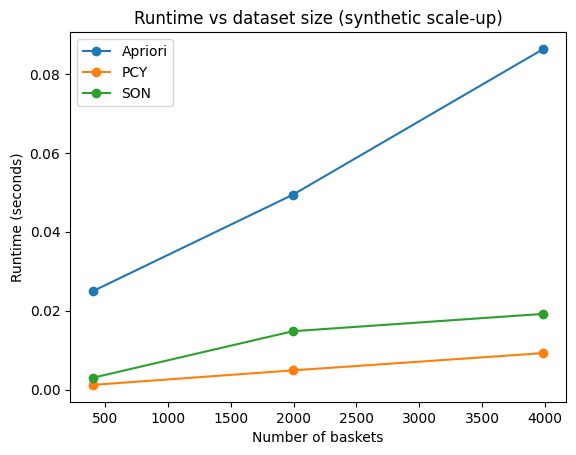

In [ ]:
plt.figure()
plt.plot(bench_df["baskets"], bench_df["apriori_sec"], marker="o", label="Apriori")
plt.plot(bench_df["baskets"], bench_df["pcy_sec"], marker="o", label="PCY")
plt.plot(bench_df["baskets"], bench_df["son_sec"], marker="o", label="SON")
plt.xlabel("Number of baskets")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime vs dataset size (synthetic scale-up)")
plt.legend()
plt.show()

## Conclusion

In this project, we modeled movies as transactions and actors as items to discover frequent co-acting patterns.  
Apriori was used as a baseline method, while PCY and SON demonstrated scalable alternatives designed for large datasets.  
All algorithms produced consistent frequent pairs, confirming correctness.  
However, scalability experiments showed that PCY significantly reduces computational cost through hashing-based pruning, making it the most efficient approach as dataset size increases.